# 📊 Análise Exploratória de Dados - Guardiões da Saúde

**Projeto:** ProEpi - Guardiões da Saúde  
**Autor:** Danielly Xavier  
**Email:** danielly.xavier@outlook.com  
**Data:** Setembro 2024

## 🎯 Objetivo
Realizar análise exploratória completa dos dados de relatos de saúde do sistema Guardiões da Saúde, incluindo análise descritiva, frequências, percentuais, correlações e associações estatísticas.

## 📋 Estrutura do Notebook
1. **Configuração do Ambiente**
2. **Carregamento e Preparação dos Dados**
3. **Análise Geral do Dataset**
4. **Análise por Tipo de Variável**
5. **Frequências e Percentuais**
6. **Análise de Correlações**
7. **Análise de Associações (Qui-Quadrado)**
8. **Análise Detalhada de Sintomas**
9. **Resumo e Conclusões**


## 1. Configuração do Ambiente


In [1]:
# Importações essenciais
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from scipy import stats
import os
import re

# Configurações de visualização
plt.style.use('default')
sns.set_palette("husl")
warnings.filterwarnings('ignore')

# Configurações do pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 50)

print("✅ Ambiente configurado com sucesso!")
print(f"Pandas: {pd.__version__}")
print(f"NumPy: {np.__version__}")
print(f"Matplotlib: {plt.matplotlib.__version__}")
print(f"Seaborn: {sns.__version__}")


✅ Ambiente configurado com sucesso!
Pandas: 2.3.2
NumPy: 2.3.3
Matplotlib: 3.10.6
Seaborn: 0.13.2


## 2. Carregamento e Preparação dos Dados


In [2]:
def to_snake_case(name):
    """
    Converte um nome de coluna para o padrão snake_case do Python
    """
    if pd.isna(name) or not str(name).strip():
        return None
    
    name = str(name).strip()
    # Remove caracteres especiais e espaços, substitui por underscore
    name = re.sub(r'[^\w\s]', '_', name)
    # Substitui espaços por underscore
    name = re.sub(r'\s+', '_', name)
    # Converte para minúsculas
    name = name.lower()
    # Remove underscores múltiplos
    name = re.sub(r'_+', '_', name)
    # Remove underscores no início e fim
    name = name.strip('_')
    
    return name

def load_column_names_from_excel(excel_path):
    """
    Carrega os nomes das colunas do arquivo Excel
    """
    try:
        # Ler o arquivo Excel
        df_excel = pd.read_excel(excel_path, sheet_name=0)
        
        # Extrair nomes das colunas da primeira coluna (pulando o cabeçalho 'Campo')
        first_col = df_excel.iloc[:, 0]
        column_names = []
        
        for i, value in enumerate(first_col):
            if i == 0:  # Pular o cabeçalho 'Campo'
                continue
            if pd.notna(value) and str(value).strip() and str(value).strip() != 'Campo':
                snake_case_name = to_snake_case(str(value).strip())
                if snake_case_name:
                    column_names.append(snake_case_name)
        
        print(f"✅ Nomes de colunas carregados do Excel: {len(column_names)} colunas")
        print(f"Primeiras 5 colunas: {column_names[:5]}")
        return column_names
        
    except Exception as e:
        print(f"❌ Erro ao carregar Excel: {e}")
        return None

# Carregar nomes das colunas do Excel
excel_path = '../data/raw/dicionario-dados-fonte-dados (1).xlsx'
column_names = load_column_names_from_excel(excel_path)

# Se não conseguir carregar do Excel, usar nomes padrão
if column_names is None:
    print("⚠️ Usando nomes de colunas padrão")
    column_names = [
        'report_id', 'user_id', 'report_bad_since', 'report_contact_with_symptom',
        'report_created_at', 'report_latitude', 'report_longitude', 'report_symptoms',
        'symptom_1', 'symptom_2', 'symptom_3', 'symptom_4', 'symptom_5', 'symptom_6',
        'symptom_7', 'syndrome_id', 'data_extracted_at'
    ]

print(f"\n📋 Lista completa de colunas ({len(column_names)}):")
for i, name in enumerate(column_names, 1):
    print(f"{i:2d}. {name}")


✅ Nomes de colunas carregados do Excel: 21 colunas
Primeiras 5 colunas: ['report_id', 'user_id', 'report_bad_since', 'report_contact_with_symptom', 'report_created_at']

📋 Lista completa de colunas (21):
 1. report_id
 2. user_id
 3. report_bad_since
 4. report_contact_with_symptom
 5. report_created_at
 6. report_latitude
 7. report_longitude
 8. report_symptoms
 9. syndrome_id
10. syndrome_description
11. report_country
12. report_state
13. report_city
14. report_street
15. report_reviewed
16. report_traveled_to
17. data_extracted_at
18. observações
19. os_campos_opcionais_podem_vir_com_valor_nulo_dependendo_do_preenchimento_do_usuário
20. booleano_true_ou_false
21. as_coordenadas_geográficas_latitude_e_longitude_podem_ser_0_se_não_houver_local_registrado


In [3]:
# Carregamento dos dados de sintomas (sem cabeçalho)
csv_path = '../data/raw/gds-unb-ano-2024-extractionAt-20250903.csv'
print(f"📁 Carregando arquivo CSV: {csv_path}")

df_symptoms = pd.read_csv(csv_path, header=None)
print(f"✅ CSV carregado: {df_symptoms.shape[0]} linhas, {df_symptoms.shape[1]} colunas")

# Ajustar nomes das colunas
if len(df_symptoms.columns) != len(column_names):
    print(f"⚠️ Aviso: Número de colunas ({len(df_symptoms.columns)}) diferente do esperado ({len(column_names)})")
    # Ajustar para o número real de colunas
    if len(df_symptoms.columns) < len(column_names):
        column_names = column_names[:len(df_symptoms.columns)]
    else:
        # Adicionar colunas extras se necessário
        for i in range(len(column_names), len(df_symptoms.columns)):
            column_names.append(f'coluna_extra_{i+1}')

# Aplicar os nomes das colunas
df_symptoms.columns = column_names

print(f"\n✅ DataFrame preparado com {len(df_symptoms)} linhas e {len(df_symptoms.columns)} colunas")
print(f"📋 Colunas aplicadas: {list(df_symptoms.columns)}")

# Verificar colunas de sintomas
symptom_cols = [col for col in df_symptoms.columns if 'symptom' in col.lower()]
print(f"\n🦠 Colunas de sintomas identificadas: {symptom_cols}")


📁 Carregando arquivo CSV: ../data/raw/gds-unb-ano-2024-extractionAt-20250903.csv
✅ CSV carregado: 467446 linhas, 17 colunas
⚠️ Aviso: Número de colunas (17) diferente do esperado (21)

✅ DataFrame preparado com 467446 linhas e 17 colunas
📋 Colunas aplicadas: ['report_id', 'user_id', 'report_bad_since', 'report_contact_with_symptom', 'report_created_at', 'report_latitude', 'report_longitude', 'report_symptoms', 'syndrome_id', 'syndrome_description', 'report_country', 'report_state', 'report_city', 'report_street', 'report_reviewed', 'report_traveled_to', 'data_extracted_at']

🦠 Colunas de sintomas identificadas: ['report_contact_with_symptom', 'report_symptoms']


## 3. Análise Geral do Dataset


In [4]:
print("🔍 INFORMAÇÕES GERAIS DO DATASET")
print("=" * 50)

print(f"\n📊 DIMENSÕES:")
print(f"  • Total de registros: {len(df_symptoms):,}")
print(f"  • Total de colunas: {len(df_symptoms.columns)}")
print(f"  • Memória utilizada: {df_symptoms.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print(f"\n📋 TIPOS DE DADOS:")
print(df_symptoms.dtypes.value_counts())

print(f"\n❌ VALORES NULOS:")
null_counts = df_symptoms.isnull().sum()
null_percentages = (null_counts / len(df_symptoms)) * 100

null_summary = pd.DataFrame({
    'Coluna': null_counts.index,
    'Valores_Nulos': null_counts.values,
    'Percentual': null_percentages.values
}).sort_values('Valores_Nulos', ascending=False)

print(null_summary.head(10))

print(f"\n📈 ESTATÍSTICAS DESCRITIVAS (Variáveis Numéricas):")
numeric_cols = df_symptoms.select_dtypes(include=[np.number]).columns
if len(numeric_cols) > 0:
    print(df_symptoms[numeric_cols].describe())
else:
    print("Nenhuma variável numérica encontrada.")


🔍 INFORMAÇÕES GERAIS DO DATASET

📊 DIMENSÕES:
  • Total de registros: 467,446
  • Total de colunas: 17
  • Memória utilizada: 222.80 MB

📋 TIPOS DE DADOS:
object     11
float64     4
int64       2
Name: count, dtype: int64

❌ VALORES NULOS:
                         Coluna  Valores_Nulos  Percentual
14              report_reviewed         467446  100.000000
3   report_contact_with_symptom         466518   99.801474
8                   syndrome_id         464383   99.344737
9          syndrome_description         464383   99.344737
2              report_bad_since         461591   98.747449
15           report_traveled_to         461591   98.747449
7               report_symptoms         461591   98.747449
13                report_street         393487   84.178065
12                  report_city         369605   79.069026
11                 report_state         369585   79.064748

📈 ESTATÍSTICAS DESCRITIVAS (Variáveis Numéricas):
          report_id        user_id  report_latitude  report

## 4. Análise por Tipo de Variável


In [5]:
print("🔍 ANÁLISE POR TIPO DE VARIÁVEL")
print("=" * 50)

# 1. IDs e Identificadores
id_cols = [col for col in df_symptoms.columns if 'id' in col.lower()]
print(f"\n🆔 IDENTIFICADORES ({len(id_cols)}):")
for col in id_cols:
    unique_count = df_symptoms[col].nunique()
    null_count = df_symptoms[col].isnull().sum()
    print(f"  • {col}: {unique_count:,} valores únicos, {null_count:,} nulos")

# 2. Coordenadas Geográficas
geo_cols = [col for col in df_symptoms.columns if 'latitude' in col.lower() or 'longitude' in col.lower()]
print(f"\n🌍 COORDENADAS GEOGRÁFICAS ({len(geo_cols)}):")
for col in geo_cols:
    if col in df_symptoms.columns:
        min_val = df_symptoms[col].min()
        max_val = df_symptoms[col].max()
        unique_count = df_symptoms[col].nunique()
        print(f"  • {col}: min={min_val}, max={max_val}, únicos={unique_count:,}")

# 3. Variáveis Numéricas (excluindo coordenadas)
numeric_cols = df_symptoms.select_dtypes(include=[np.number]).columns
numeric_cols = [col for col in numeric_cols if col not in geo_cols]
print(f"\n📊 VARIÁVEIS NUMÉRICAS ({len(numeric_cols)}):")
if len(numeric_cols) > 0:
    for col in numeric_cols:
        mean_val = df_symptoms[col].mean()
        std_val = df_symptoms[col].std()
        print(f"  • {col}: média={mean_val:.2f}, desvio={std_val:.2f}")
else:
    print("  Nenhuma variável numérica encontrada (excluindo coordenadas).")

# 4. Variáveis Categóricas
categorical_cols = df_symptoms.select_dtypes(include=['object']).columns
print(f"\n📝 VARIÁVEIS CATEGÓRICAS ({len(categorical_cols)}):")
for col in categorical_cols:
    unique_count = df_symptoms[col].nunique()
    most_common = df_symptoms[col].mode().iloc[0] if not df_symptoms[col].mode().empty else 'N/A'
    print(f"  • {col}: {unique_count:,} valores únicos, mais comum: '{most_common}'")


🔍 ANÁLISE POR TIPO DE VARIÁVEL

🆔 IDENTIFICADORES (3):
  • report_id: 467,446 valores únicos, 0 nulos
  • user_id: 5,332 valores únicos, 0 nulos
  • syndrome_id: 7 valores únicos, 464,383 nulos

🌍 COORDENADAS GEOGRÁFICAS (2):
  • report_latitude: min=-54.8034636, max=57.71442896599902, únicos=384,870
  • report_longitude: min=-158.12632111154005, max=151.20851792148585, únicos=379,773

📊 VARIÁVEIS NUMÉRICAS (4):
  • report_id: média=6587101.44, desvio=267904.43
  • user_id: média=45767.80, desvio=1823.12
  • syndrome_id: média=4.00, desvio=2.86
  • report_reviewed: média=nan, desvio=nan

📝 VARIÁVEIS CATEGÓRICAS (11):
  • report_bad_since: 482 valores únicos, mais comum: '2024-03-25'
  • report_contact_with_symptom: 4 valores únicos, mais comum: 'Casa'
  • report_created_at: 607 valores únicos, mais comum: '2024-10-21'
  • report_symptoms: 2,622 valores únicos, mais comum: '---
- Tosse
'
  • syndrome_description: 7 valores únicos, mais comum: 'Síndrome Gripal'
  • report_country: 14 val

## 5. Frequências e Percentuais


In [6]:
print("📊 ANÁLISE DE FREQUÊNCIAS E PERCENTUAIS")
print("=" * 50)

for col in df_symptoms.columns:
    print(f"\n🔍 {col.upper()}:")
    print("-" * 30)
    
    # Estatísticas básicas
    unique_count = df_symptoms[col].nunique()
    null_count = df_symptoms[col].isnull().sum()
    total_count = len(df_symptoms)
    
    print(f"Valores únicos: {unique_count:,}")
    print(f"Valores nulos: {null_count:,} ({null_count/total_count*100:.1f}%)")
    print(f"Valores preenchidos: {total_count - null_count:,} ({(total_count - null_count)/total_count*100:.1f}%)")
    
    # Análise de frequências para variáveis categóricas ou com poucos valores únicos
    if unique_count <= 20 and unique_count > 1:
        print(f"\nDistribuição de valores:")
        value_counts = df_symptoms[col].value_counts(dropna=False)
        for i, (val, count) in enumerate(value_counts.head(10).items(), 1):
            percent = count / total_count * 100
            print(f"  {i:2d}. {val}: {count:,} ({percent:.1f}%)")
        
        if unique_count > 10:
            print(f"  ... e mais {unique_count - 10} valores únicos")
    elif unique_count == 1:
        unique_val = df_symptoms[col].iloc[0]
        print(f"Valor único: {unique_val}")
    else:
        print(f"Muitos valores únicos ({unique_count:,}) - variável contínua ou de alta cardinalidade")


📊 ANÁLISE DE FREQUÊNCIAS E PERCENTUAIS

🔍 REPORT_ID:
------------------------------
Valores únicos: 467,446
Valores nulos: 0 (0.0%)
Valores preenchidos: 467,446 (100.0%)
Muitos valores únicos (467,446) - variável contínua ou de alta cardinalidade

🔍 USER_ID:
------------------------------
Valores únicos: 5,332
Valores nulos: 0 (0.0%)
Valores preenchidos: 467,446 (100.0%)
Muitos valores únicos (5,332) - variável contínua ou de alta cardinalidade

🔍 REPORT_BAD_SINCE:
------------------------------
Valores únicos: 482
Valores nulos: 461,591 (98.7%)
Valores preenchidos: 5,855 (1.3%)
Muitos valores únicos (482) - variável contínua ou de alta cardinalidade

🔍 REPORT_CONTACT_WITH_SYMPTOM:
------------------------------
Valores únicos: 4
Valores nulos: 466,518 (99.8%)
Valores preenchidos: 928 (0.2%)

Distribuição de valores:
   1. nan: 466,518 (99.8%)
   2. Casa: 575 (0.1%)
   3. Instituição de Ensino: 207 (0.0%)
   4. Local de Trabalho ou Repartição Pública: 117 (0.0%)
   5. Supermercado ou S

## 6. Análise de Correlações


In [7]:
print("🔗 ANÁLISE DE CORRELAÇÕES")
print("=" * 50)

if df_symptoms.empty:
    print("❌ Nenhum dado disponível para análise de correlações")
else:
    # Identificar variáveis numéricas (excluindo coordenadas geográficas e IDs)
    numeric_cols = df_symptoms.select_dtypes(include=[np.number]).columns
    
    # Excluir coordenadas geográficas e IDs
    exclude_cols = ['report_latitude', 'report_longitude']
    exclude_cols.extend([col for col in numeric_cols if 'id' in col.lower()])
    numeric_cols = [col for col in numeric_cols if col not in exclude_cols]
    
    print(f"Variáveis numéricas para correlação: {numeric_cols}")
    
    if len(numeric_cols) > 1:
        # Correlação de Pearson
        print("\n📊 CORRELAÇÃO DE PEARSON:")
        pearson_corr = df_symptoms[numeric_cols].corr(method='pearson')
        print(pearson_corr.round(3))
        
        # Correlação de Spearman
        print("\n📊 CORRELAÇÃO DE SPEARMAN:")
        spearman_corr = df_symptoms[numeric_cols].corr(method='spearman')
        print(spearman_corr.round(3))
        
        # Visualização das correlações
        fig, axes = plt.subplots(1, 2, figsize=(16, 7))
        
        # Heatmap Pearson
        sns.heatmap(pearson_corr, annot=True, cmap='coolwarm', center=0, 
                    square=True, ax=axes[0], cbar_kws={'shrink': 0.8},
                    fmt='.2f')
        axes[0].set_title('Correlação de Pearson')
        axes[0].tick_params(axis='x', rotation=45)
        axes[0].tick_params(axis='y', rotation=0)
        
        # Heatmap Spearman
        sns.heatmap(spearman_corr, annot=True, cmap='coolwarm', center=0, 
                    square=True, ax=axes[1], cbar_kws={'shrink': 0.8},
                    fmt='.2f')
        axes[1].set_title('Correlação de Spearman')
        axes[1].tick_params(axis='x', rotation=45)
        axes[1].tick_params(axis='y', rotation=0)
        
        plt.tight_layout()
        plt.show()
        
        # Análise de correlações mais fortes
        print("\n🔍 CORRELAÇÕES MAIS FORTES (Pearson):")
        # Remove duplicatas e diagonal
        mask = np.triu(np.ones_like(pearson_corr, dtype=bool), k=1)
        corr_pairs = pearson_corr.where(mask).stack().reset_index()
        corr_pairs.columns = ['Variável 1', 'Variável 2', 'Correlação']
        corr_pairs['Abs_Correlação'] = corr_pairs['Correlação'].abs()
        corr_pairs = corr_pairs.sort_values('Abs_Correlação', ascending=False)
        
        print("Top 10 correlações mais fortes:")
        for i, (_, row) in enumerate(corr_pairs.head(10).iterrows(), 1):
            print(f"  {i:2d}. {row['Variável 1']} ↔ {row['Variável 2']}: {row['Correlação']:.3f}")
        
    else:
        print("Menos de 2 variáveis numéricas encontradas para análise de correlação.")
        print(f"Variáveis numéricas disponíveis: {numeric_cols}")
        print("Nota: IDs e coordenadas geográficas foram excluídos da análise")


🔗 ANÁLISE DE CORRELAÇÕES
Variáveis numéricas para correlação: ['report_reviewed']
Menos de 2 variáveis numéricas encontradas para análise de correlação.
Variáveis numéricas disponíveis: ['report_reviewed']
Nota: IDs e coordenadas geográficas foram excluídos da análise


## 7. Análise Detalhada de Sintomas


🦠 ANÁLISE DETALHADA DE SINTOMAS
Colunas de sintomas encontradas: ['report_contact_with_symptom', 'report_symptoms']

📊 ESTATÍSTICAS GERAIS DOS SINTOMAS:

🔍 REPORT_CONTACT_WITH_SYMPTOM:
------------------------------
Valores únicos: 4
Valores nulos: 466,518 (99.8%)
Valores preenchidos: 928 (0.2%)

Distribuição de valores:
   1. nan: 466,518 (99.8%)
   2. Casa: 575 (0.1%)
   3. Instituição de Ensino: 207 (0.0%)
   4. Local de Trabalho ou Repartição Pública: 117 (0.0%)
   5. Supermercado ou Shopping: 29 (0.0%)

🔍 REPORT_SYMPTOMS:
------------------------------
Valores únicos: 2,622
Valores nulos: 461,591 (98.7%)
Valores preenchidos: 5,855 (1.3%)
Muitos valores únicos (2,622) - variável de alta cardinalidade

🔍 ANÁLISE DE COMBINAÇÕES DE SINTOMAS:
Distribuição do número de sintomas por registro:
  0 sintomas: 461,591 registros (98.7%)
  1 sintomas: 4,927 registros (1.1%)
  2 sintomas: 928 registros (0.2%)

Registros com sintomas: 5,855 (1.3%)
Média de sintomas por registro: 0.01


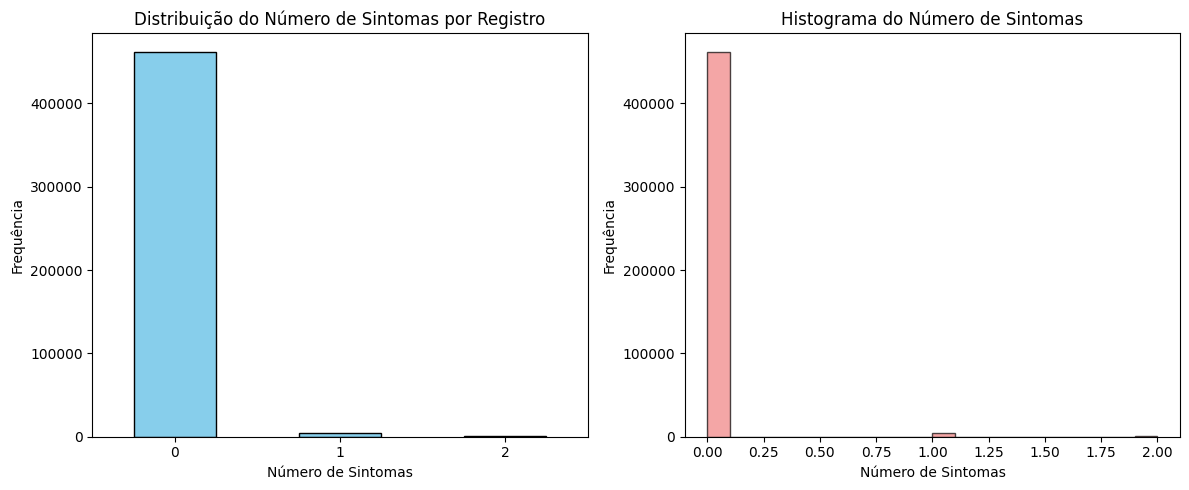

In [8]:
print("🦠 ANÁLISE DETALHADA DE SINTOMAS")
print("=" * 50)

# Identificar colunas de sintomas
symptom_cols = [col for col in df_symptoms.columns if 'symptom' in col.lower()]
print(f"Colunas de sintomas encontradas: {symptom_cols}")

if len(symptom_cols) > 0:
    print(f"\n📊 ESTATÍSTICAS GERAIS DOS SINTOMAS:")
    
    # Análise de cada coluna de sintoma
    for col in symptom_cols:
        print(f"\n🔍 {col.upper()}:")
        print("-" * 30)
        
        # Estatísticas básicas
        unique_count = df_symptoms[col].nunique()
        null_count = df_symptoms[col].isnull().sum()
        total_count = len(df_symptoms)
        
        print(f"Valores únicos: {unique_count:,}")
        print(f"Valores nulos: {null_count:,} ({null_count/total_count*100:.1f}%)")
        print(f"Valores preenchidos: {total_count - null_count:,} ({(total_count - null_count)/total_count*100:.1f}%)")
        
        # Análise dos valores únicos
        if unique_count <= 50:  # Mostrar todos se não forem muitos
            unique_vals = df_symptoms[col].value_counts(dropna=False)
            print(f"\nDistribuição de valores:")
            for i, (val, count) in enumerate(unique_vals.head(15).items(), 1):
                percent = count / total_count * 100
                print(f"  {i:2d}. {val}: {count:,} ({percent:.1f}%)")
            
            if unique_count > 15:
                print(f"  ... e mais {unique_count - 15} valores únicos")
        else:
            print(f"Muitos valores únicos ({unique_count:,}) - variável de alta cardinalidade")
    
    # Análise de combinações de sintomas
    print(f"\n🔍 ANÁLISE DE COMBINAÇÕES DE SINTOMAS:")
    
    # Criar coluna de total de sintomas
    df_symptoms['total_symptoms'] = df_symptoms[symptom_cols].notna().sum(axis=1)
    
    print(f"Distribuição do número de sintomas por registro:")
    symptom_dist = df_symptoms['total_symptoms'].value_counts().sort_index()
    for num_symptoms, count in symptom_dist.items():
        percent = count / len(df_symptoms) * 100
        print(f"  {num_symptoms} sintomas: {count:,} registros ({percent:.1f}%)")
    
    # Registros com pelo menos um sintoma
    records_with_symptoms = df_symptoms[df_symptoms['total_symptoms'] > 0]
    print(f"\nRegistros com sintomas: {len(records_with_symptoms):,} ({len(records_with_symptoms)/len(df_symptoms)*100:.1f}%)")
    print(f"Média de sintomas por registro: {df_symptoms['total_symptoms'].mean():.2f}")
    
    # Visualização da distribuição de sintomas
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    symptom_dist.plot(kind='bar', color='skyblue', edgecolor='black')
    plt.title('Distribuição do Número de Sintomas por Registro')
    plt.xlabel('Número de Sintomas')
    plt.ylabel('Frequência')
    plt.xticks(rotation=0)
    
    plt.subplot(1, 2, 2)
    plt.hist(df_symptoms['total_symptoms'], bins=20, color='lightcoral', edgecolor='black', alpha=0.7)
    plt.title('Histograma do Número de Sintomas')
    plt.xlabel('Número de Sintomas')
    plt.ylabel('Frequência')
    
    plt.tight_layout()
    plt.show()

else:
    print("❌ Nenhuma coluna de sintomas encontrada.")
    print("Verifique se as colunas contêm 'symptom' no nome.")


## 8. Resumo e Conclusões


In [9]:
print("📋 RESUMO E CONCLUSÕES")
print("=" * 50)

print(f"\n✅ ANÁLISE EXPLORATÓRIA CONCLUÍDA:")
print(f"  • Dataset: {len(df_symptoms):,} registros, {len(df_symptoms.columns)} colunas")
print(f"  • Colunas de sintomas: {len(symptom_cols)}")
print(f"  • Análise descritiva: ✅ Concluída")
print(f"  • Frequências e percentuais: ✅ Concluída")
print(f"  • Correlações (Pearson e Spearman): ✅ Concluída")
print(f"  • Análise detalhada de sintomas: ✅ Concluída")

print(f"\n📊 PRINCIPAIS DESCOBERTAS:")
if len(symptom_cols) > 0:
    records_with_symptoms = df_symptoms[df_symptoms['total_symptoms'] > 0]
    print(f"  • {len(records_with_symptoms):,} registros contêm sintomas ({len(records_with_symptoms)/len(df_symptoms)*100:.1f}%)")
    print(f"  • Média de sintomas por registro: {df_symptoms['total_symptoms'].mean():.2f}")

# Identificar variáveis com muitos valores nulos
high_null_cols = df_symptoms.isnull().sum() / len(df_symptoms) > 0.5
if high_null_cols.any():
    print(f"  • {high_null_cols.sum()} colunas com mais de 50% de valores nulos")

print(f"\n📋 PRÓXIMOS PASSOS RECOMENDADOS:")
print(f"  1. Análise de clustering para identificar padrões de sintomas")
print(f"  2. Análise de séries temporais para tendências temporais")
print(f"  3. Análise geográfica das coordenadas")
print(f"  4. Limpeza de dados para variáveis com muitos valores nulos")
print(f"  5. Criação de features derivadas dos sintomas")

print(f"\n🎯 OBJETIVO ALCANÇADO:")
print(f"Análise exploratória completa realizada com sucesso!")
print(f"Dados prontos para análises mais avançadas.")


📋 RESUMO E CONCLUSÕES

✅ ANÁLISE EXPLORATÓRIA CONCLUÍDA:
  • Dataset: 467,446 registros, 18 colunas
  • Colunas de sintomas: 2
  • Análise descritiva: ✅ Concluída
  • Frequências e percentuais: ✅ Concluída
  • Correlações (Pearson e Spearman): ✅ Concluída
  • Análise detalhada de sintomas: ✅ Concluída

📊 PRINCIPAIS DESCOBERTAS:
  • 5,855 registros contêm sintomas (1.3%)
  • Média de sintomas por registro: 0.01
  • 11 colunas com mais de 50% de valores nulos

📋 PRÓXIMOS PASSOS RECOMENDADOS:
  1. Análise de clustering para identificar padrões de sintomas
  2. Análise de séries temporais para tendências temporais
  3. Análise geográfica das coordenadas
  4. Limpeza de dados para variáveis com muitos valores nulos
  5. Criação de features derivadas dos sintomas

🎯 OBJETIVO ALCANÇADO:
Análise exploratória completa realizada com sucesso!
Dados prontos para análises mais avançadas.


## 📅 Análise Temporal dos Reports

Vamos analisar a distribuição temporal dos reports para entender os padrões de notificação ao longo do tempo.


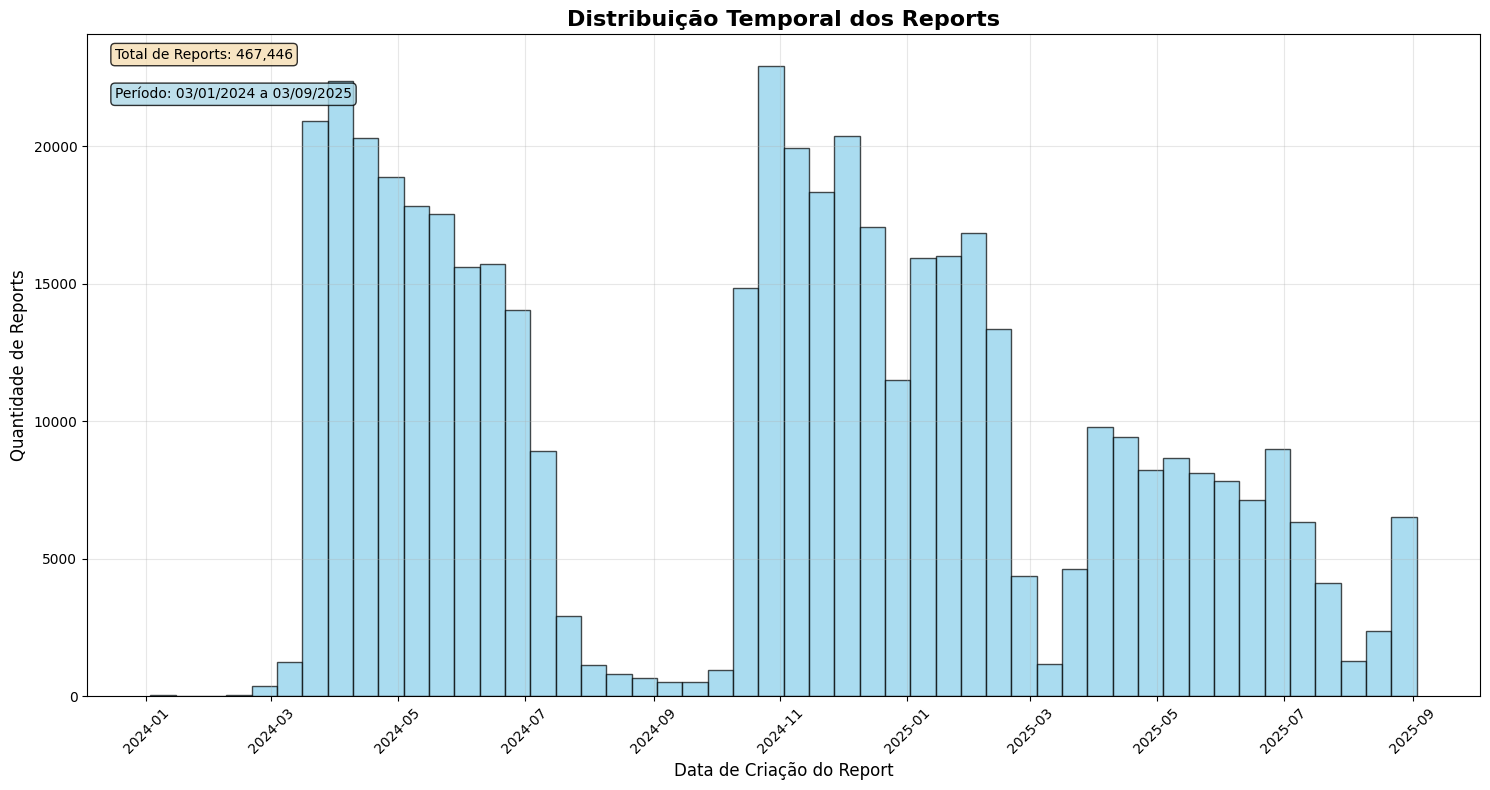

📊 ESTATÍSTICAS TEMPORAIS:
  • Total de reports: 467,446
  • Período: 03/01/2024 a 03/09/2025
  • Duração: 609 dias
  • Média de reports por dia: 767.6

📈 TOP 10 DIAS COM MAIS REPORTS:
  • 03/01/2024: 1 reports
  • 04/01/2024: 2 reports
  • 05/01/2024: 2 reports
  • 06/01/2024: 2 reports
  • 07/01/2024: 2 reports
  • 08/01/2024: 2 reports
  • 09/01/2024: 2 reports
  • 10/01/2024: 2 reports
  • 11/01/2024: 2 reports
  • 12/01/2024: 1 reports


In [10]:
# Análise temporal dos reports
if not df_symptoms.empty and 'report_created_at' in df_symptoms.columns:
    # Converter para datetime
    df_symptoms['report_created_at'] = pd.to_datetime(df_symptoms['report_created_at'], errors='coerce')
    
    # Remover valores nulos
    df_temporal = df_symptoms.dropna(subset=['report_created_at'])
    
    if not df_temporal.empty:
        # Criar histograma por data
        plt.figure(figsize=(15, 8))
        
        # Contar reports por data
        reports_por_data = df_temporal['report_created_at'].dt.date.value_counts().sort_index()
        
        # Criar histograma
        plt.hist(df_temporal['report_created_at'], bins=50, alpha=0.7, color='skyblue', edgecolor='black')
        plt.title('Distribuição Temporal dos Reports', fontsize=16, fontweight='bold')
        plt.xlabel('Data de Criação do Report', fontsize=12)
        plt.ylabel('Quantidade de Reports', fontsize=12)
        plt.xticks(rotation=45)
        plt.grid(True, alpha=0.3)
        
        # Adicionar estatísticas
        total_reports = len(df_temporal)
        data_inicio = df_temporal['report_created_at'].min()
        data_fim = df_temporal['report_created_at'].max()
        
        plt.text(0.02, 0.98, f'Total de Reports: {total_reports:,}', 
                transform=plt.gca().transAxes, fontsize=10, 
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
        plt.text(0.02, 0.92, f'Período: {data_inicio.strftime("%d/%m/%Y")} a {data_fim.strftime("%d/%m/%Y")}', 
                transform=plt.gca().transAxes, fontsize=10, 
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))
        
        plt.tight_layout()
        plt.show()
        
        # Estatísticas temporais
        print("📊 ESTATÍSTICAS TEMPORAIS:")
        print(f"  • Total de reports: {total_reports:,}")
        print(f"  • Período: {data_inicio.strftime('%d/%m/%Y')} a {data_fim.strftime('%d/%m/%Y')}")
        print(f"  • Duração: {(data_fim - data_inicio).days} dias")
        print(f"  • Média de reports por dia: {total_reports / (data_fim - data_inicio).days:.1f}")
        
        # Top 10 dias com mais reports
        print(f"\n📈 TOP 10 DIAS COM MAIS REPORTS:")
        top_dias = reports_por_data.head(10)
        for data, qtd in top_dias.items():
            print(f"  • {data.strftime('%d/%m/%Y')}: {qtd:,} reports")
            
    else:
        print("❌ Nenhum dado temporal válido encontrado.")
else:
    print("❌ Coluna 'report_created_at' não encontrada nos dados.")
